### Individual Homework

#### Enter your name here:
**Julian Alfredo Pabon Sanclemente**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Analysis of movies IMDB dataset**

We will look at a ***subset*** sample of movies, taken from the [Kaggle IMDB 5000 movie dataset](https://www.kaggle.com/carolzhangdc/imdb-5000-movie-dataset)

In [2]:
movies = pd.read_csv('../Data/movies.csv')
movies

,title,genre,director,year,duration,gross,budget,cast_facebook_likes,votes,reviews,rating
0,Avatar,Action,James Cameron,2009,178,760505847,237000000,4834,886204,3777,7.9
1,Titanic,Drama,James Cameron,1997,194,658672302,200000000,45223,793059,2843,7.7
2,Jurassic World,Action,Colin Trevorrow,2015,124,652177271,150000000,8458,418214,1934,7.0
3,The Avengers,Action,Joss Whedon,2012,173,623279547,220000000,87697,995415,2425,8.1
4,The Dark Knight,Action,Christopher Nolan,2008,152,533316061,185000000,57802,1676169,5312,9.0
...,...,...,...,...,...,...,...,...,...,...,...
2956,Locker 13,Thriller,Bruce Dellis,2014,95,2468,300000,2048,241,15,4.8
2957,The Ghastly Love of Johnny X,Comedy,Paul Bunnell,2012,106,2436,2000000,1611,344,113,5.7
2958,Detention of the Dead,Comedy,Alex Craig Mann,2012,87,1332,500000,2251,2038,49,4.6
2959,The Trials of Darryl Hunt,Crime,Ricki Stern,2006,106,1111,200000,2,771,21,7.7


Besides the obvious variables of `title`, `genre`, `director`, `year`, and `duration`, the rest of the variables are as follows:

-   `gross` : The gross earnings in the US box office, not adjusted for inflation
-   `budget`: The movie's budget
-   `cast_facebook_likes`: the number of facebook likes cast memebrs received
-   `votes`: the number of people who voted for (or rated) the movie in IMDB
-   `reviews`: the number of reviews for that movie
-   `rating`: IMDB average rating

**Produce a table with the count of movies by genre, ranked in descending order**


In [9]:
movies_by_genere = movies.groupby(
    'genre')\
    .agg({'title': 'count'})\
    .reset_index(drop=False)\
    .sort_values(by='title', ascending=False)

display(movies_by_genere)

,genre,title
4,Comedy,848
0,Action,738
7,Drama,498
1,Adventure,288
5,Crime,202
3,Biography,135
10,Horror,131
2,Animation,35
9,Fantasy,28
6,Documentary,25


**Produce a table with the average gross earning and budget (`gross` and `budget`) by genre. Calculate a variable `return_on_budget` which shows how many \$ did a movie make at the box office for each \$ of its budget. Ranked genres by this `return_on_budget` in descending order**

In [16]:
movie_gross_budget = movies.groupby(
    'genre')\
    .agg({'gross': 'mean', 
          'budget': 'mean'})\
    .reset_index()\
    .assign(retunr_on_budget=lambda x: x['gross'] / x['budget']) \
    .sort_values(by='retunr_on_budget', ascending=False)


display(movie_gross_budget)

,genre,gross,budget,retunr_on_budget
11,Musical,9.208400e+07,3.189500e+06,28.870983
8,Family,1.491605e+08,1.483333e+07,10.055763
16,Western,2.082188e+07,3.465000e+06,6.009202
6,Documentary,1.735397e+07,5.887852e+06,2.947420
10,Horror,3.771374e+07,1.350492e+07,2.792593
9,Fantasy,4.240884e+07,1.758214e+07,2.412040
4,Comedy,4.263055e+07,2.444632e+07,1.743843
12,Mystery,6.753302e+07,3.921875e+07,1.721958
2,Animation,9.843379e+07,6.170143e+07,1.595324
3,Biography,4.520181e+07,2.854370e+07,1.583600


In [29]:
movies.assign(
    return_on_budget=lambda x: x['gross'] / x['budget'])\
    .groupby('genre')\
    .agg({
        'return_on_budget': 'mean',
        'gross' : 'mean',
        'budget' : 'mean'
          })\
    .reset_index()\
    .sort_values(by=('return_on_budget'), ascending=False)

,genre,return_on_budget,gross,budget
10,Horror,88.304785,3.771374e+07,1.350492e+07
3,Biography,22.280597,4.520181e+07,2.854370e+07
11,Musical,18.817819,9.208400e+07,3.189500e+06
8,Family,14.076490,1.491605e+08,1.483333e+07
6,Documentary,8.698550,1.735397e+07,5.887852e+06
16,Western,7.062800,2.082188e+07,3.465000e+06
9,Fantasy,6.681969,4.240884e+07,1.758214e+07
2,Animation,5.009095,9.843379e+07,6.170143e+07
4,Comedy,3.713990,4.263055e+07,2.444632e+07
12,Mystery,3.269397,6.753302e+07,3.921875e+07


**Produce a table that shows the top 15 directors who have created the highest gross revenue in the box office. Don't just show the total gross amount, but also the mean, median, and standard deviation per director**

In [59]:
# top 15 directors with the highest gross revenue
top_directors = (
    movies.groupby('director')
    .agg({'gross': ['sum', 'mean', 'median', 'std']})
    .reset_index()
)

top_directors.columns = ['Director', 'Sum of Gross Revenues', 'Mean', 'Median', 'Standard Deviation']

top_directors = top_directors.sort_values(by='Sum of Gross Revenues', ascending=False).head(15)

display(top_directors)

,Director,Sum of Gross Revenues,Mean,Median,Standard Deviation
1233,Steven Spielberg,4014061704,1.745244e+08,164435221.0,1.014211e+08
861,Michael Bay,2231242537,1.716340e+08,138396624.0,1.271616e+08
1267,Tim Burton,2071275480,1.294547e+08,76519172.0,1.087269e+08
1161,Sam Raimi,2014600898,2.014601e+08,234903076.0,1.621266e+08
513,James Cameron,1909725910,3.182877e+08,175562880.5,3.091713e+08
208,Christopher Nolan,1813227576,2.266534e+08,196667606.5,1.872241e+08
429,George Lucas,1741418480,3.482837e+08,380262555.0,1.461939e+08
1122,Robert Zemeckis,1619309108,1.245622e+08,100853835.0,9.130028e+07
216,Clint Eastwood,1378321100,7.254322e+07,46700000.0,7.548741e+07
387,Francis Lawrence,1358501971,2.717004e+08,281666058.0,1.354370e+08


**Produce a table that describes how ratings are distributed by genre. We don't want just the mean, but also, min, max, median, SD and some kind of a histogram or density graph that visually shows how ratings are distributed.**

In [12]:
ratings_by_genre = movies.groupby('genre')\
    .agg(
        {'rating': ['mean', 'min', 'max', 'median', 'std']})

ratings_by_genre.columns = ['Mean', 'Minimum', 'Maximum', 'Median', 'Standard Deviation']

display(ratings_by_genre)

,Mean,Minimum,Maximum,Median,Standard Deviation
genre,,,,,
Action,6.232249,2.1,9.0,6.30,1.030362
Adventure,6.506597,2.3,8.6,6.60,1.093881
Animation,6.651429,4.5,8.0,6.90,0.968131
Biography,7.114074,4.5,8.9,7.20,0.759827
Comedy,6.109670,1.9,8.8,6.20,1.023075
Crime,6.915347,4.8,9.3,6.90,0.849356
Documentary,6.660000,1.6,8.5,7.40,1.766588
Drama,6.731526,2.1,8.8,6.80,0.916993
Family,6.500000,5.7,7.9,5.90,1.216553


Text(0, 0.5, 'Frequency')

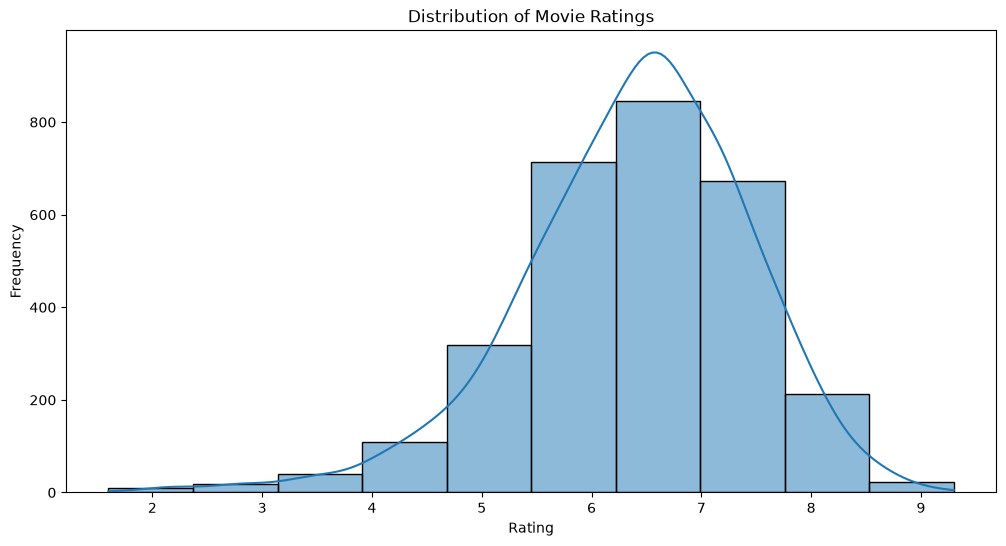

In [17]:
plt.figure(figsize=(12, 6))
sns.histplot(data=movies, x='rating', bins=10, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

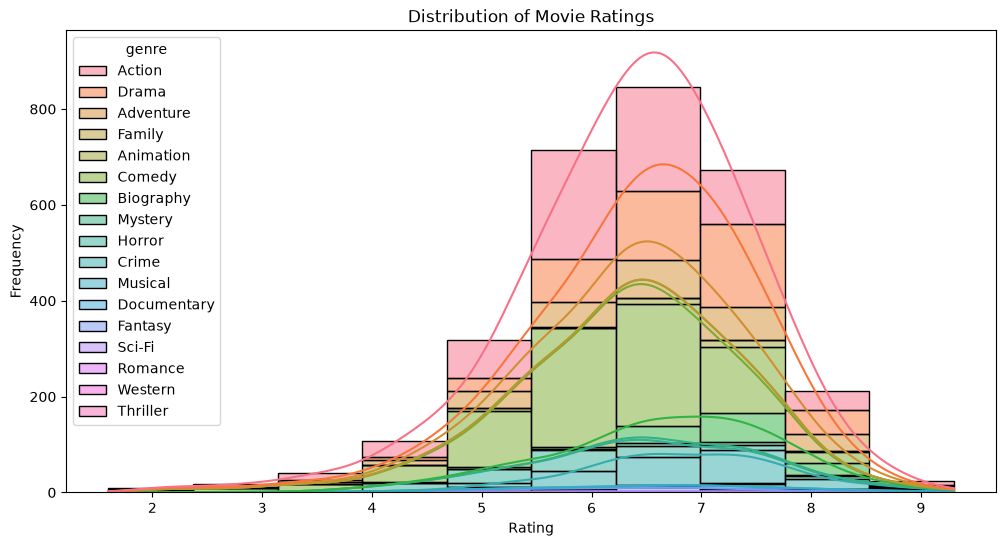

In [19]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=movies, 
    x='rating', 
    bins=10, 
    kde=True,
    hue='genre',
    multiple='stack')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')

**Challenge - Produce a table of your own choosing, something you think is important/interesting to have data for, justify your result by writting a 2 sentence explanation/interpretation of the result.**

#### Use visualisation to answer the following questions

**Examine the relationship between `gross` and `cast_facebook_likes`. Produce a scatterplot and write one sentence discussing whether the number of facebook likes that the cast has received is likely to be a good predictor of how much money a movie will make at the box office. What variable are you going to map to the Y- and X- axes?**

Text(0, 0.5, 'Gross Revenues')

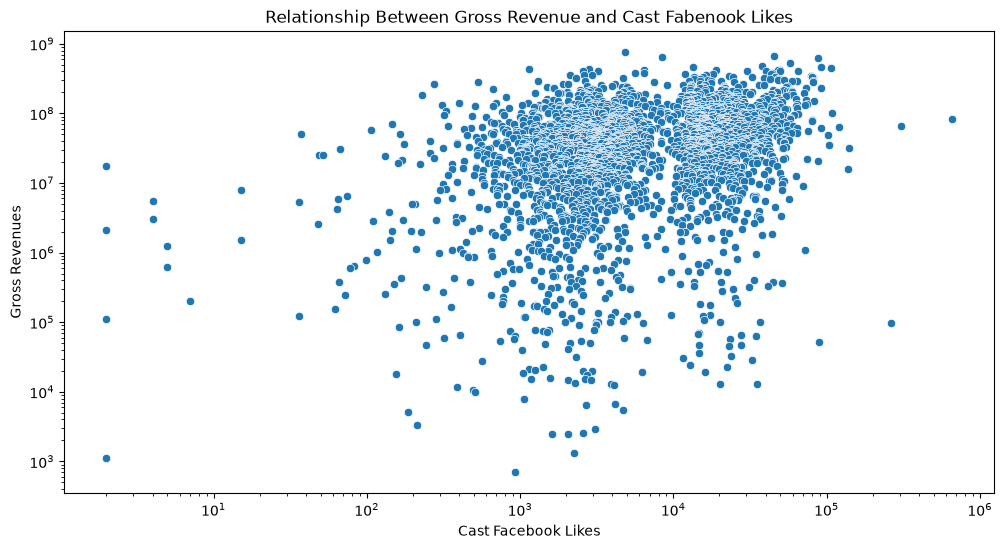

In [44]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=movies,
    x='cast_facebook_likes',
    y='gross')
plt.xscale('log')
plt.yscale('log')
plt.title('Relationship Between Gross Revenue and Cast Fabenook Likes')
plt.xlabel('Cast Facebook Likes')
plt.ylabel('Gross Revenues')


This **scatterplot** using logaritmic scales on both axis chart allows to see that there is a **weak positive trend** relationship between the number of likes of the cast on facebook and the gross revenues. If I where to explore this feature to a model, **I would probably avoid it**, datapoints show a very wide variance.

**Examine the relationship between `gross` and `budget`. Produce a scatterplot and write one sentence discussing whether budget is likely to be a good predictor of how much money a movie will make at the box office.**

Text(0, 0.5, 'Budget')

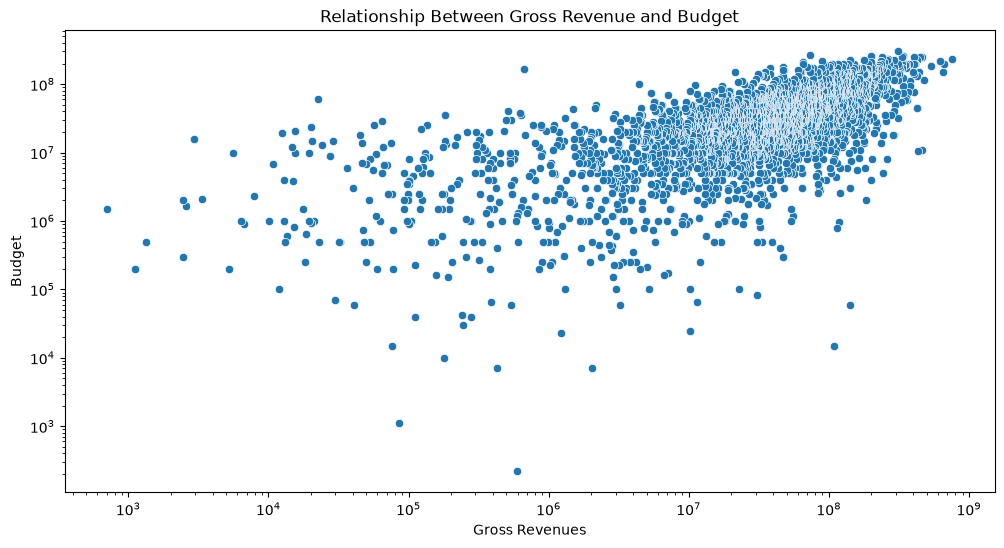

In [24]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=movies,
    x='gross',
    y='budget',
    )
plt.xscale('log')
plt.yscale('log')
plt.title('Relationship Between Gross Revenue and Budget')
plt.xlabel('Gross Revenues')
plt.ylabel('Budget')


It is possible to visualize a **positive correlation** between budget and gross revenues. Low budget movies are prone to have *more variance* in its revenues, while high budget movies seem to have a **positive monotonic increment** on the revenue showing less variance. 

**Examine the relationship between `gross` and `rating`. Produce a scatterplot, faceted by `genre` and discuss whether IMDB ratings are likely to be a good predictor of how much money a movie will make at the box office. Is there anything strange in this dataset?**

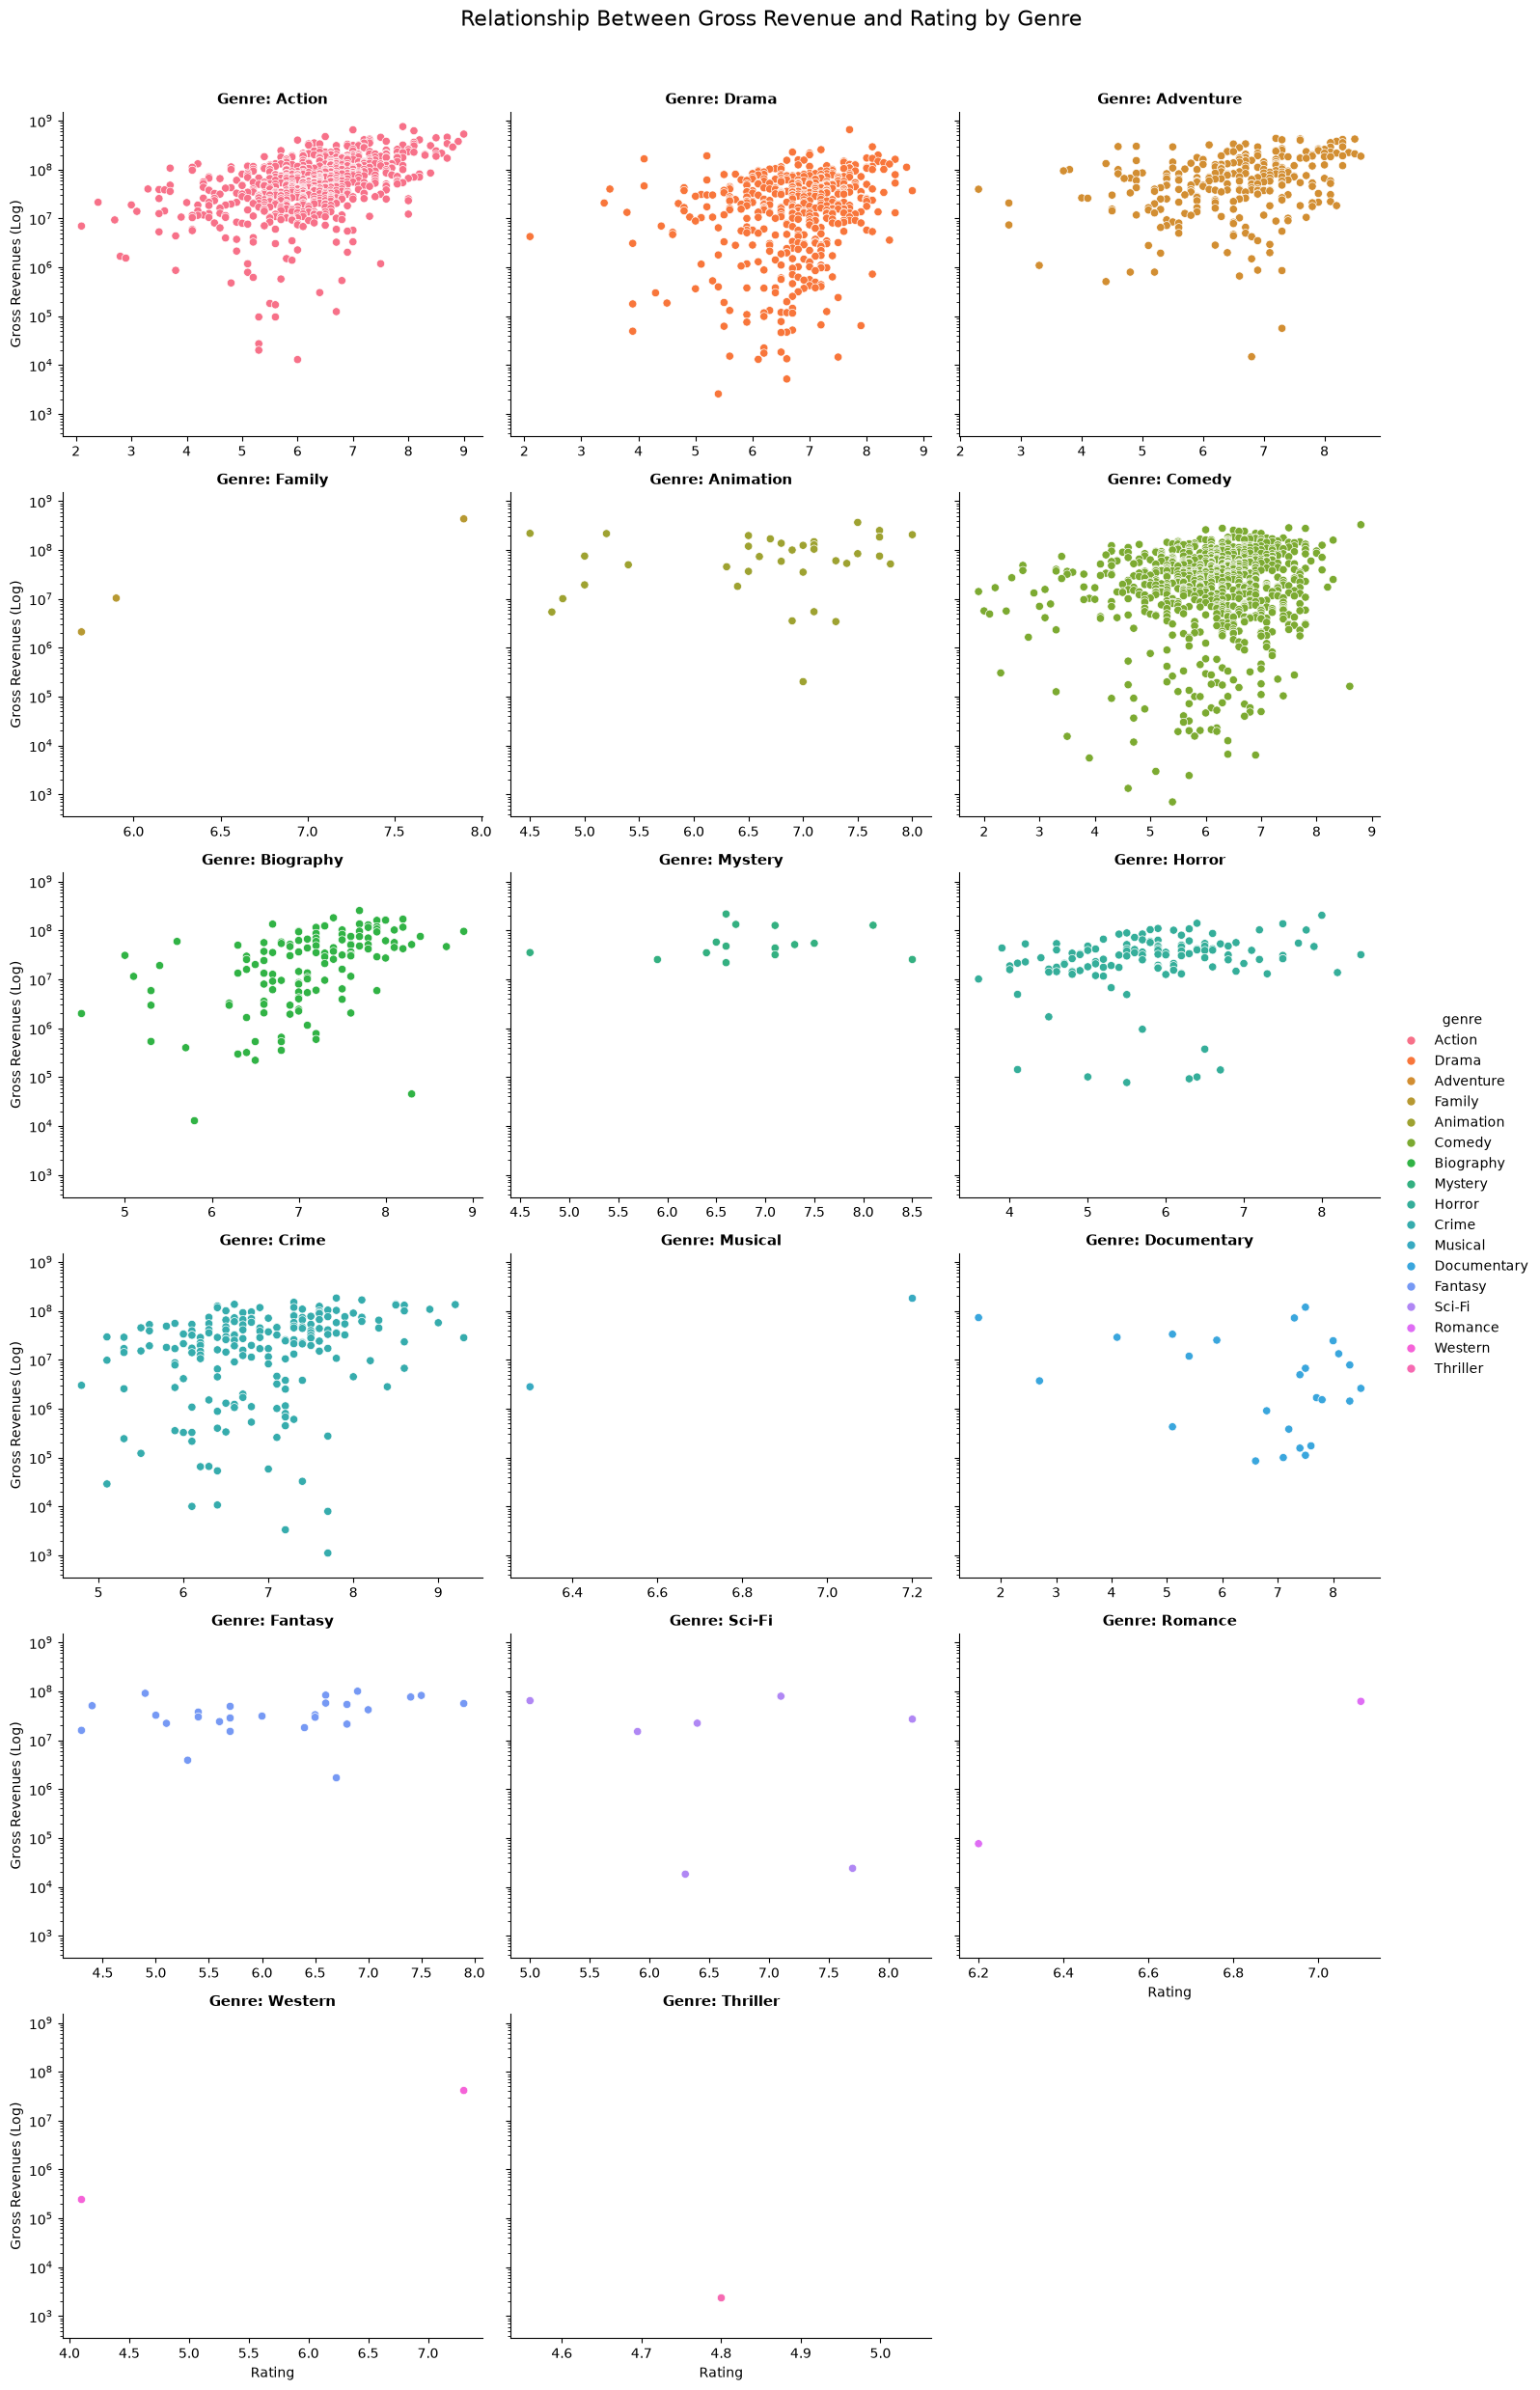

In [61]:
(
    sns.relplot(
        data=movies,
        x='rating',
        y='gross',
        col='genre',
        col_wrap=3,
        height=4,
        aspect=1.2,
        hue='genre',
        facet_kws={'sharex': False, 'sharey': True}
    )
    .set_titles(col_template='Genre: {col_name}', size=11, weight='bold')
    .set_axis_labels('Rating', 'Gross Revenues (Log)')
    .set(yscale='log')
    .fig.suptitle('Relationship Between Gross Revenue and Rating by Genre', fontsize=16, y=1.03)
)

plt.show()

There are some genres in which there are not enough data to conclude like:
- Thriller
- western
- romance
- sci-fi
- Fantasy
- Documentary
- Musical

**Challenge - Produce a visualisation of your choosing, something you think is important to explore/investigate visually. Do make it a comprehensive graph and not a single histogram or density plot. Make it publication ready, label your axes, give it a title, choose colouring options, appropirately formatted text etc.**

### Deliverables

Poduce a clean, stand-alone notebook (or HTML export) with:

All tables/plots properly labeled

Brief interpretations where requested

Upload final HTML/Notebook.